In [13]:
## imports
import subprocess

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
from matplotlib import ticker as ticker

## Suppress annoying pandas warnings
import warnings
warnings.filterwarnings("ignore")

from misc.plot_helpers import *


## Plot 1

In [ ]:
TRUTH="/lustre1/g/paed_yangwl/snakesch/data/svhet2/1kg/benchmark/variants_T2T-CHM13_sv_insdel_sym_HGSVC2024v1.0.annot.vcf.gz"
ORIG="/lustre1/g/paed_yangwl/snakesch/data/svhet2/1kg/sv/lumpy/final_lumpy_gt-smoove.genotyped.vcf.gz"

## Generated by p02_sv_summary.sh
truth_set_svtype_summary = "/lustre1/g/paed_yangwl/snakesch/work/SVhet/tables/truth-set-svtype-summary.txt"
callset_svtype_summary = "/lustre1/g/paed_yangwl/snakesch/work/SVhet/tables/final_lumpy_gt-smoove-svtype-summary.txt"

## SV types
truth_set_svtype_df = pd.read_csv(truth_set_svtype_summary, sep="\t").set_index("Sample").drop(["HET_DUP", "HOM_DUP"], axis=1)
callset_svtype_df = pd.read_csv(callset_svtype_summary, sep="\t").set_index("Sample").drop(["HET_INS", "HOM_INS"], axis=1)

t_mean = truth_set_svtype_df.mean().round(0).astype(int)
c_mean = callset_svtype_df.mean().round(0).astype(int)

## SV sizes
proc = subprocess.run(f"bcftools query -f \"%SVLEN\" {TRUTH}", shell=True, capture_output=True)
out = filter(lambda x: x.lstrip("-").isnumeric(), proc.stdout.decode().split("\n"))
truth_sizes = tuple(map(int, out))

proc = subprocess.run(f"bcftools query -f \"%SVLEN\" {ORIG}", shell=True, capture_output=True)
out = filter(lambda x: x.lstrip("-").isnumeric(), proc.stdout.decode().split("\n"))
orig_sizes = tuple(map(int, out))

## CIPOS and CIEND
proc = subprocess.run(f"bcftools filter -i \'SVTYPE = \"DEL\"\' {ORIG} | bcftools query -f \'%INFO/CIPOS\t%INFO/CIEND\' ", shell=True, capture_output=True)
_out = proc.stdout.decode().split("\n")[:-1]
cipos, ciend = [list(map(int, ci.split("\t")[0].split(","))) for ci in _out], [list(map(int, ci.split("\t")[1].split(","))) for ci in _out]

cipos_lo, cipos_hi = np.array([x[0] for x in cipos]), np.array([x[1] for x in cipos])
ciend_lo, ciend_hi = np.array([x[0] for x in ciend]), np.array([x[1] for x in ciend])


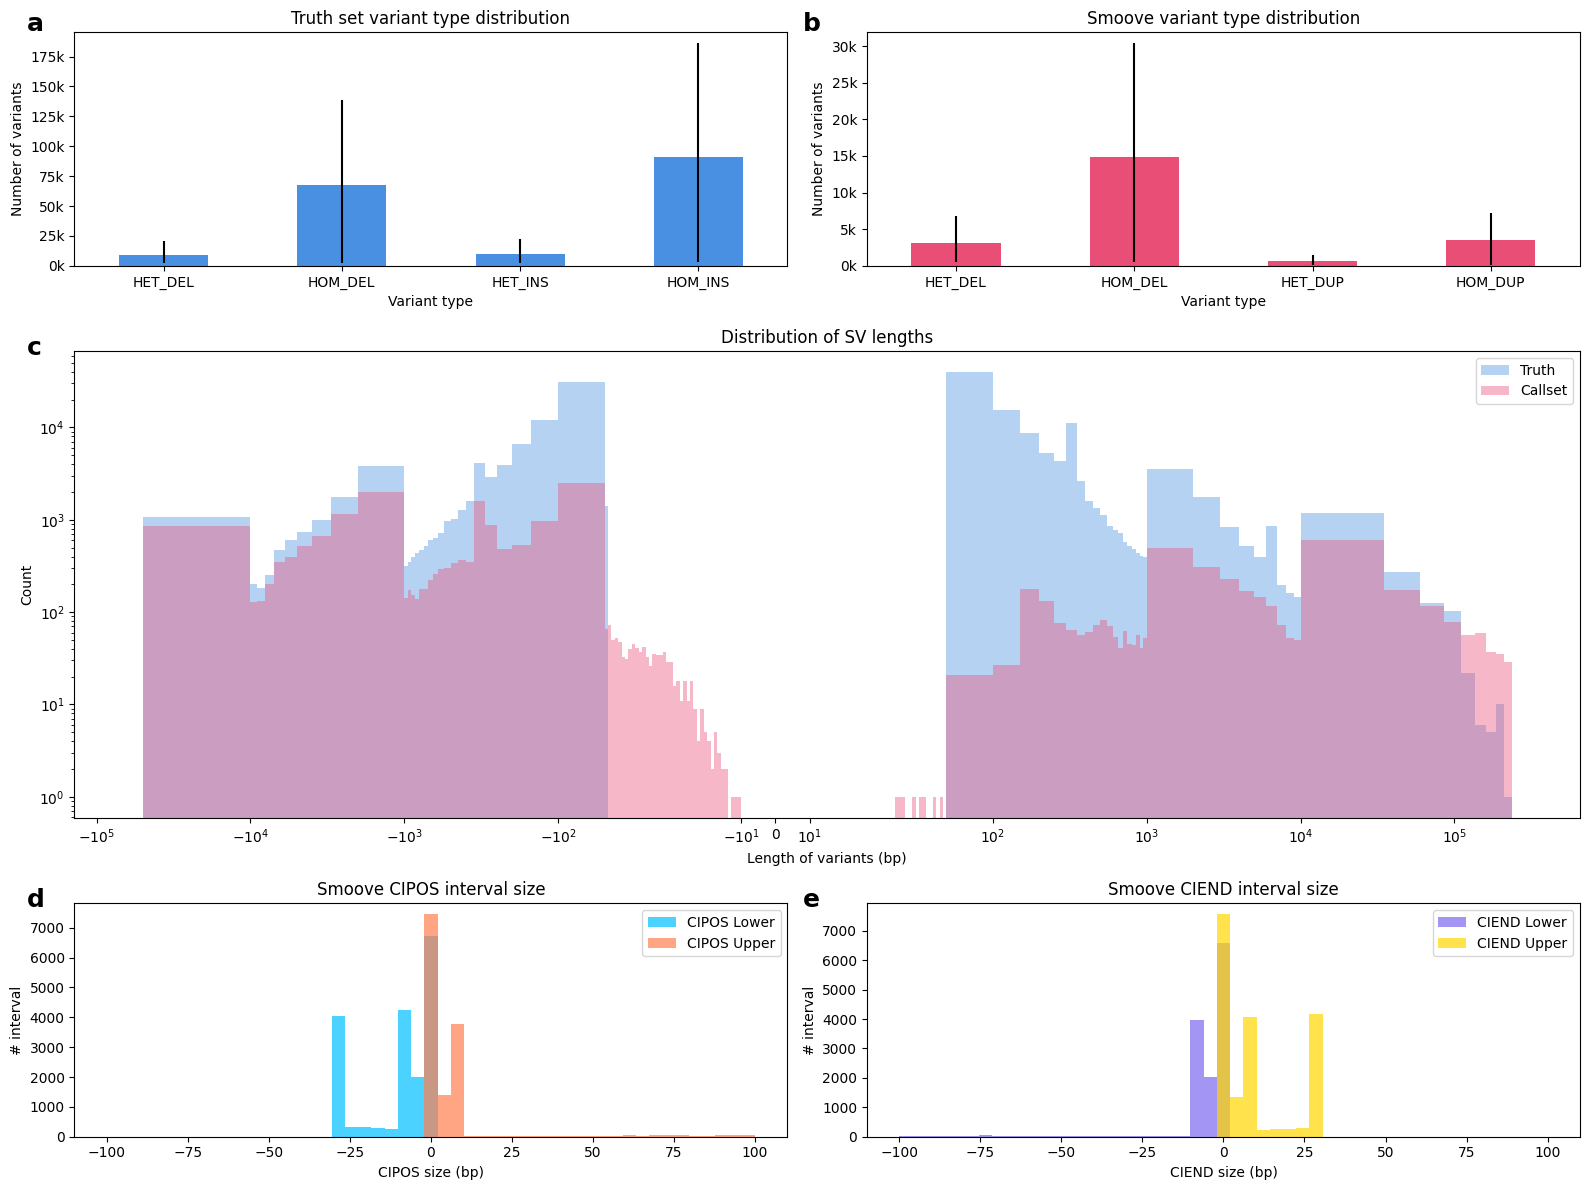

In [4]:
fig = plt.figure(constrained_layout=True, figsize=(16, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[1,2,1])

# Top row: bar charts
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])

# Format y axis for thousands
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1_000)}k'))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1_000)}k'))

# Barplots
t_mean.plot.bar(yerr=[truth_set_svtype_df.min(), truth_set_svtype_df.max()], ax=ax1, rot=0, color='#4a90e2')
ax1.set_title("Truth set variant type distribution")
ax1.set_xlabel("Variant type")
ax1.set_ylabel("Number of variants")

c_mean.plot.bar(yerr=[callset_svtype_df.min(), callset_svtype_df.max()], ax=ax2, rot=0, color='#e94e77')
ax2.set_title("Smoove variant type distribution")
ax2.set_xlabel("Variant type")
ax2.set_ylabel("Number of variants")

# Middle row: histogram
ax_hist = fig.add_subplot(gs[1,:])

bins = np.concatenate((
    [-50000, -10000],
    np.arange(-10000, -1000, 1000),
    np.arange(-1000, -50, 50),
    np.arange(-50, 0, 1),
    np.arange(0, 50, 1),
    np.arange(50, 1000, 50),
    np.arange(1000, 10000, 1000),
    np.arange(10000, 250000, 25000)
))

ax_hist.hist(truth_sizes, bins=bins, alpha=0.4, label='Truth', color='#4a90e2')
ax_hist.hist(orig_sizes, bins=bins, alpha=0.4, label='Callset', color='#e94e77')
ax_hist.set_xscale('symlog', linthresh=50)  # symmetric log scale near zero
ax_hist.set_yscale('log')
ax_hist.set_xlabel('Length of variants (bp)')
ax_hist.set_ylabel('Count')
ax_hist.legend()
ax_hist.set_title('Distribution of SV lengths')

# Bottom row: CIPOS/CIEND
ax3 = fig.add_subplot(gs[2, 0])
ax4 = fig.add_subplot(gs[2, 1])

bins_ci = np.linspace(-100, 100)
ax3.hist(cipos_lo, bins=bins_ci, color='deepskyblue', alpha=0.7, label='CIPOS Lower')
ax3.hist(cipos_hi, bins=bins_ci, color='coral', alpha=0.7, label='CIPOS Upper')
ax3.set_title("Smoove CIPOS interval size")
ax3.set_xlabel("CIPOS size (bp)")
ax3.set_ylabel("# interval")
ax3.legend()
ax4.hist(ciend_lo, bins=bins_ci, color='mediumslateblue', alpha=0.7, label='CIEND Lower')
ax4.hist(ciend_hi, bins=bins_ci, color='gold', alpha=0.7, label='CIEND Upper')
ax4.set_title("Smoove CIEND interval size")
ax4.set_xlabel("CIEND size (bp)")
ax4.set_ylabel("# interval")
ax4.legend()

fig.text(0.02, 0.97, 'a', fontsize=18, fontweight='bold')
fig.text(0.505, 0.97, 'b', fontsize=18, fontweight='bold')
fig.text(0.02, 0.7, 'c', fontsize=18, fontweight='bold')
fig.text(0.02, 0.24, 'd', fontsize=18, fontweight='bold')
fig.text(0.505, 0.24, 'e', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.savefig("plots/figure_1_sv_summary.png", dpi=300)

## Plot 2

In [14]:
## Main 
labels = ["SVhet", "duphold", "duphold+svhet", "paragraph", "paragraph+svhet"]

## Paths
root = "/lustre1/g/paed_yangwl/snakesch/tmp/test_svhet/truvari"
root_template = "/lustre1/g/paed_yangwl/snakesch/tmp/test_svhet/{}/truvari"

sample_manifest = pd.read_csv("/lustre1/g/paed_yangwl/snakesch/work/SVhet/tables/bam_statistics.tsv", sep="\t")
samples = sample_manifest["sample"]

unfiltered = get_metrics_dist(root, samples, "orig", label="unfiltered")
svhet = get_metrics_dist(root, samples, "final", label="SVhet")
duphold = get_metrics_dist(root_template.format("duphold"), samples, "final", label="duphold")
duphold_svhet = get_metrics_dist(root_template.format("duphold+svhet"), samples, "final", label="duphold+svhet")

graphtyper2 = get_metrics_dist(root_template.format("graphtyper2"), samples, "final", label="graphtyper2")

paragraph = get_metrics_dist(root_template.format("paragraph"), samples, "final", label="paragraph")
paragraph_svhet = get_metrics_dist(root_template.format("paragraph+svhet"), samples, "final", label="paragraph+svhet")

# pangenie = get_metrics_dist(root_template.format("pangenie"), samples, "final", label="pangenie")

prec_rec_f1 = pd.concat((unfiltered, svhet, duphold, duphold_svhet, paragraph, paragraph_svhet, graphtyper2), axis=1).round(3)

unfiltered = get_counts(root, samples, "orig", label="unfiltered")
svhet = get_counts(root, samples, "final", label="SVhet")
duphold = get_counts(root_template.format("duphold"), samples, "final", label="duphold")
duphold_svhet = get_counts(root_template.format("duphold+svhet"), samples, "final", label="duphold+svhet")

paragraph = get_counts(root_template.format("paragraph"), samples, "final", label="paragraph")
paragraph_svhet = get_counts(root_template.format("paragraph+svhet"), samples, "final", label="paragraph+svhet")

graphtyper2 = get_counts(root_template.format("graphtyper2"), samples, "final", label="graphtyper2")
# pangenie = get_counts(root_template.format("pangenie"), samples, "final", label="pangenie")

tp_fp_fn_counts = pd.concat((unfiltered, svhet, duphold, duphold_svhet, paragraph, paragraph_svhet, graphtyper2), axis=1).round(0).astype(int)

unfiltered = get_fp_and_recall(root, samples, "orig", label="unfiltered")
svhet = get_fp_and_recall(root, samples, "final", label="SVhet")
duphold = get_fp_and_recall(root_template.format("duphold"), samples, "final", label="duphold")
duphold_svhet = get_fp_and_recall(root_template.format("duphold+svhet"), samples, "final", label="duphold+svhet")

paragraph = get_fp_and_recall(root_template.format("paragraph"), samples, "final", label="paragraph")
paragraph_svhet = get_fp_and_recall(root_template.format("paragraph+svhet"), samples, "final", label="paragraph+svhet")

# graphtyper2 = get_fp_and_recall(root_template.format("graphtyper2"), samples, "final", label="graphtyper2")
# pangenie = get_fp_and_recall(root_template.format("pangenie"), samples, "final", label="pangenie") ## Not plotted in main figure

perf = consolidate_across_tools(unfiltered, svhet, duphold, duphold_svhet, paragraph, paragraph_svhet, labels=labels)

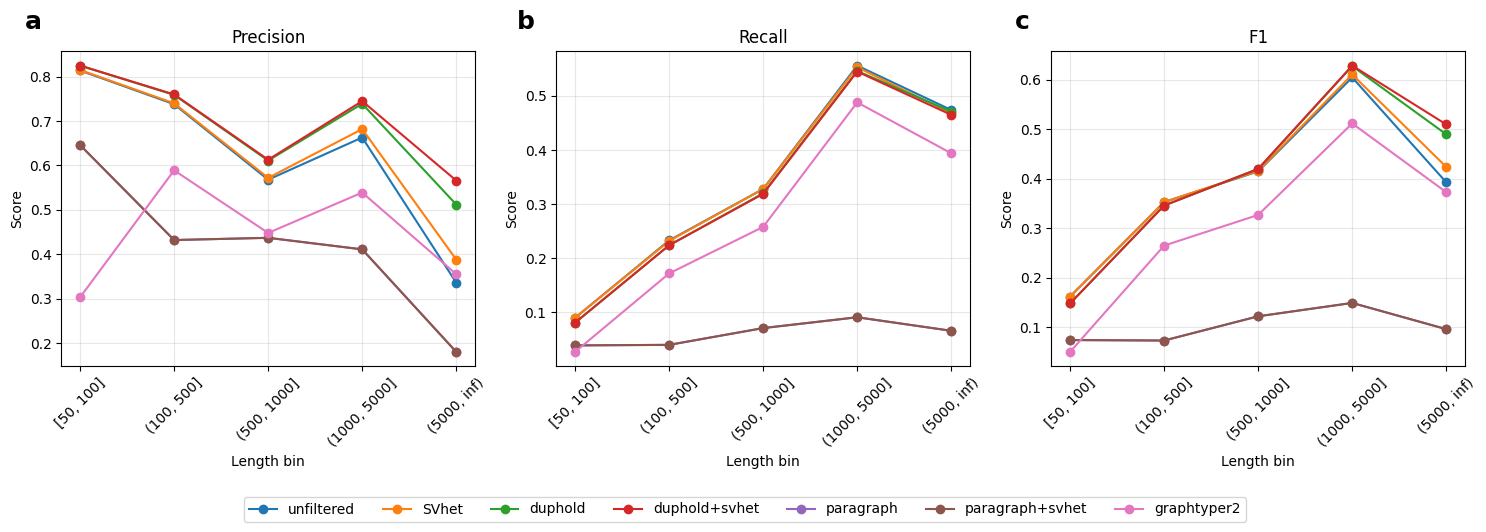

In [15]:
# Plot precision, recall, and F1 across tools and length bins
metrics = ['precision', 'recall', 'f1']
tools = prec_rec_f1.columns.get_level_values(0).unique()
length_bins = prec_rec_f1.index.get_level_values('length').unique()

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)

for i, metric in enumerate(metrics):
    ax = axes[i]
    for tool in tools:
        # Select values for each tool and metric
        y = prec_rec_f1.xs(metric, level='metric').loc[:, tool]
        ax.plot(length_bins, y.values, marker='o', label=tool)
    ax.set_title(metric.capitalize())
    ax.set_xlabel('Length bin')
    ax.set_ylabel("Score")
    ax.grid(True, alpha=0.3)
    ax.set_xticks(np.arange(len(length_bins)))
    ax.set_xticklabels(length_bins, rotation=45)

# Put the legend underneath all subplots, closer to the plots
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc='lower center', ncol=len(tools), fontsize=10, bbox_to_anchor=(0.5, -0.03))

fig.text(0.02, 0.97, 'a', fontsize=18, fontweight='bold')
fig.text(0.348, 0.97, 'b', fontsize=18, fontweight='bold')
fig.text(0.68, 0.97, 'c', fontsize=18, fontweight='bold')

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("plots/figure_2_precision_recall_f1.png", dpi=300)


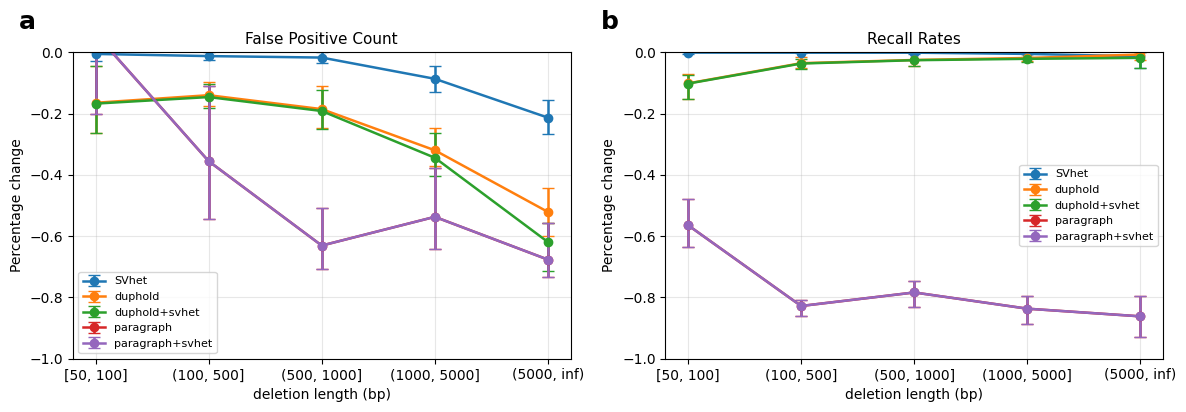

In [16]:
## Plot 3
tools = list(perf.keys())
lengths = perf[tools[0]].index
x = np.arange(len(lengths))
x_labels = [str(iv) for iv in lengths]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for metric, ax in zip(['fp', 'recall'], axes):
    for label in tools:
        dfm = perf[label]

        mean_tbl = dfm.xs('mean', level='stat', axis=1)
        min_tbl  = dfm.xs('min',  level='stat', axis=1)
        max_tbl  = dfm.xs('max',  level='stat', axis=1)
        
        y   = mean_tbl[metric].reindex(lengths).to_numpy(dtype=float)
        ylo = (y - min_tbl[metric].reindex(lengths).to_numpy(dtype=float))
        yhi = (max_tbl[metric].reindex(lengths).to_numpy(dtype=float) - y)
        yerr = np.vstack([ylo, yhi])
        
        ax.errorbar(x, y, yerr=yerr, marker='o', capsize=4,
                    linewidth=1.8, label=label)

    title_map = {"fp": "False Positive Count", "recall": "Recall Rates"}
    
    ax.set_xticks(x, x_labels)
    ax.set_ylim(-1.0, 0.0)
    ax.set_title(f"{title_map[metric]}", fontsize=11)
    ax.set_xlabel("deletion length (bp)")
    ax.set_ylabel("Percentage change")
    ax.grid(True, alpha=0.3)
    ax.legend(title="", fontsize=8)

fig.text(0.02, 0.97, 'a', fontsize=18, fontweight='bold')
fig.text(0.505, 0.97, 'b', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.savefig("plots/figure_3_fp_recall_reduction.png", dpi=300)


## Plot 4

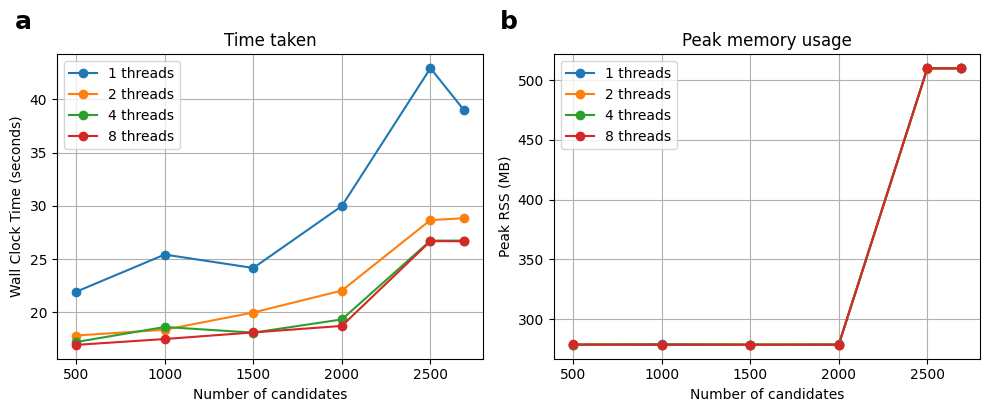

In [12]:
time_profile = "/lustre1/g/paed_yangwl/snakesch/tmp/test_svhet/time.txt"

time_profile_df = pd.read_csv(time_profile, sep="\t", header=None, names=["threads", "bin", "walltime", "rss"])
time_profile_df["rss"] = time_profile_df["rss"] / 1024

def time_to_seconds(tstr):
    min_part, sec_part = tstr.split(':')
    return int(min_part) * 60 + float(sec_part)

df = time_profile_df

df['walltime_sec'] = df['walltime'].apply(time_to_seconds)

threads = [1, 2, 4, 8]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Walltime plot
for thr in threads:
    subset = df[df['threads'] == thr]
    ax1.plot(subset['bin'], subset['walltime_sec'], marker='o', label=f'{thr} threads')
ax1.set_xlabel('Number of candidates')
ax1.set_ylabel('Wall Clock Time (seconds)')
ax1.set_title('Time taken')
ax1.legend()
ax1.grid(True)

# RSS plot
for thr in threads:
    subset = df[df['threads'] == thr]
    ax2.plot(subset['bin'], subset['rss'], marker='o', label=f'{thr} threads')
ax2.set_xlabel('Number of candidates')
ax2.set_ylabel('Peak RSS (MB)')
ax2.set_title('Peak memory usage')
ax2.legend()
ax2.grid(True)

fig.text(0.02, 0.97, 'a', fontsize=18, fontweight='bold')
fig.text(0.505, 0.97, 'b', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.savefig("plots/figure_4_time_memory.png", dpi=300)